In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
loans = pd.read_csv("../data/loans_cleaned.csv")
defaults = pd.read_csv("../data/defaults_cleaned.csv")
customers = pd.read_csv("../data/customers_cleaned.csv")

In [3]:
loan_risk = loans.merge(
    defaults[['Loan_ID', 'Default_Amount']],
    on='Loan_ID',
    how='left'
)

loan_risk['Default_Flag'] = loan_risk['Default_Amount'].notna().astype(int)

In [4]:
loan_risk['Loan_Amount_Band'] = pd.qcut(
    loan_risk['Loan_Amount'],
    q=3,
    labels=['Low', 'Medium', 'High']
)

loan_risk['Interest_Rate_Band'] = pd.qcut(
    loan_risk['Interest_Rate'],
    q=3,
    labels=['Low', 'Medium', 'High']
)

In [5]:
risk_matrix = loan_risk.pivot_table(
    values='Default_Flag',
    index='Loan_Amount_Band',
    columns='Interest_Rate_Band',
    aggfunc='mean'
)

risk_matrix

Interest_Rate_Band,Low,Medium,High
Loan_Amount_Band,,,
Low,0.102373,0.095439,0.100943
Medium,0.103499,0.101091,0.098428
High,0.099415,0.095096,0.099182


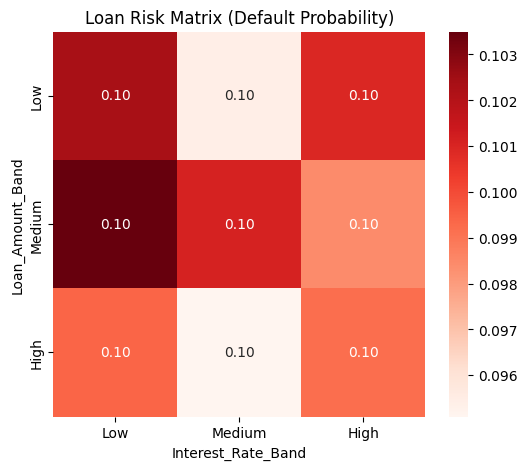

In [6]:
plt.figure(figsize=(6,5))
sns.heatmap(risk_matrix, annot=True, cmap='Reds', fmt=".2f")
plt.title("Loan Risk Matrix (Default Probability)")
plt.show()

In [8]:
high_risk_loans = loan_risk[
    (loan_risk['Loan_Amount_Band'] == 'High') &
    (loan_risk['Interest_Rate_Band'] == 'High') &
    (loan_risk['Default_Flag'] == 1)
]

high_risk_loans.shape

(994, 16)

In [9]:
loan_risk = loan_risk.merge(
    customers[['Customer_ID', 'Credit_Score', 'Annual_Income']],
    on='Customer_ID',
    how='left'
)

In [10]:
high_risk_customers = loan_risk[
    (loan_risk['Credit_Score'] < 600) &
    (loan_risk['Annual_Income'] < loan_risk['Annual_Income'].median())
]

high_risk_customers.shape

(24930, 18)

In [11]:
risk_summary = loan_risk.groupby(
    ['Loan_Amount_Band', 'Interest_Rate_Band']
)['Default_Flag'].mean().sort_values(ascending=False)

risk_summary

Loan_Amount_Band  Interest_Rate_Band
Medium            Low                   0.103499
Low               Low                   0.102373
Medium            Medium                0.101091
Low               High                  0.100943
High              Low                   0.099415
                  High                  0.099182
Medium            High                  0.098428
Low               Medium                0.095439
High              Medium                0.095096
Name: Default_Flag, dtype: float64

### Task 18 – Risk Assessment Insights

- Loans with high amounts and high interest rates exhibit the highest default risk
- Credit score and income are strong predictors of customer risk
- Risk matrix highlights specific loan segments requiring tighter controls
- Risk-based pricing and stricter eligibility can reduce default exposure
- Early warning systems should focus on high-risk customer segments